# RL - Chapter 4 - DP - Car Rental


In [18]:
from toc import generate_toc

path = 'ch_4_DP_p2_car_rental.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 4 - DP - Car Rental](#rl-chapter-4-dp-car-rental)
  - [Environment - Physics](#environment-physics)
  - [Policy](#policy)
  - [Dynamic Programming Agent](#dynamic-programming-agent)
  - [Run Policy Iteration](#run-policy-iteration)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)

## Environment - Physics


In [20]:
# Jack’s Car Rental problem environment
class CarRentalEnv:
    def __init__(self):
        # define state space
        self.n_cols = 21    # max car in location 1
        self.n_rows = 21    # max car in location 2
        n_states = self.n_rows * self.n_cols
        self.states = [(i, j) for i in range(self.n_rows) for j in range(self.n_cols)]
        self.n_states = n_states

        # action space
        # actions: -5 to +5
        # -n: move n cars from loc 1 to loc 2
        # +n: move n cars from loc 2 to loc 1
        self.actions = np.arange(-5, 6)  # 5 6
        self.n_actions = len(self.actions)

        # costs and rewards
        self.move_cost = 2
        self.rental_reward = 10
        self.max_cars = 20
        self.max_move = 5

        # constants for Poisson probabilities
        self.poisson_ub = 9
        self.l_rent_1 = 3
        self.l_rent_2 = 4
        self.l_return_1 = 3
        self.l_return_2 = 2

## Policy


In [21]:
# define Policy
class Policy:
    def __init__(self, env: CarRentalEnv):
        # policy pi(a|s) : an action for each state
        self.pi = np.zeros((env.n_rows, env.n_cols), dtype=int)
        self.initialize_policy()

    def initialize_policy(self):
        self.pi[:] = 0

## Dynamic Programming Agent


In [22]:
# Dynamic Programming Agent
class DP_Agent:
    def __init__(self, env: CarRentalEnv):

        # initialize environment(dynamics) and policy
        self.env = env              # Environment
        self.policy = Policy(env)   # Policy

        # setting hyperparameters
        self.gamma = 0.9            # Discount factor
        self.theta = 1e-1           # Convergence threshold
        self.max_policy_iter = 10
        self.max_value_iter = 50

        # initialize value function
        self.V = np.zeros((self.env.n_rows, self.env.n_cols), dtype=np.float32)  # V[s] = value of state s
        self.v_sum = 0.0

        # counters for diagnostics
        self.n_policy_imp = 0
        self.n_policy_eval_sweep = 0
        self.n_value_iter = 0
        self.poisson_cache = dict()  # cache for Poisson probabilities

        #
        print("Precomputing Poisson probabilities...")
        self.create_probs_cache()

    def reset(self):
        self.V = np.zeros((self.env.n_rows, self.env.n_cols), dtype=np.float32)
        self.policy.initialize_policy()
        self.n_policy_imp = 0
        self.n_policy_eval_sweep = 0
        self.n_value_iter = 0

    # --------------------------------------------------------------------------
    # Policy Iteration and Value Iteration
    # --------------------------------------------------------------------------

    def policy_iteration(self):
        print("Starting policy iteration...")
        self.n_policy_imp = 0
        while True:
            self.policy_evaluation()
            policy_stable = self.policy_improvement()
            self.v_sum = np.sum(self.V)

            self.n_policy_imp += 1
            if policy_stable:
                break
            if self.n_policy_imp > self.max_policy_iter:
                print(f"Policy iteration did not converge within {self.max_policy_iter} iterations.")
                break

    def value_iteration(self):
        print("Starting value iteration...")
        self.n_value_iter = 0
        for i in range(self.max_value_iter):
            delta = 0.0
            self.n_value_iter += 1
            for s in self.env.states:
                v_old = self.V[s]
                action_values = []
                for action in self.env.actions:
                    action_value = self.get_expected_return(state=s, action=action)
                    action_values.append(action_value)
                v_new = max(action_values)
                self.V[s] = v_new
                delta = max(delta, abs(v_old - v_new))

            print(f"Value iteration #{i + 1}, delta: {delta:.4f}")
            if delta < self.theta:
                print("Value iteration converged.")
                break
        # derive policy from optimal value function
        print("Deriving policy from optimal value function...")
        for s in self.env.states:
            best_action = self.get_improved_action(state=s)
            self.policy.pi[s] = best_action

    # --------------------------------------------------------------------------
    # Policy evaluation and improvement
    # --------------------------------------------------------------------------

    def policy_evaluation(self):
        print(f"Starting policy evaluation #{self.n_policy_eval_sweep + 1}...")
        while True:
            delta = 0.0
            for s in self.env.states:
                # expected_return
                action_values = self.get_expected_return(state=s, action=self.policy.pi[s])
                v_new = action_values
                # v_new = np.sum(action_values)

                # update value function and track max change for convergence check
                delta = max(delta, abs(self.V[s] - v_new))
                self.V[s] = v_new

            self.n_policy_eval_sweep += 1
            if delta < self.theta:
                break

    def policy_improvement(self):
        print(f"Starting policy improvement #{self.n_policy_imp + 1}...")
        policy_stable = True
        for s in self.env.states:
            # update policy
            curr_action = self.policy.pi[s]
            new_action = self.get_improved_action(state=s)
            self.policy.pi[s] = new_action

            # check if policy is stable
            if curr_action != new_action:
                policy_stable = False

        return policy_stable

    def get_improved_action(self, state):
        action_returns = []
        for action in self.env.actions:
            action_values = self.get_expected_return(state=state, action=action)
            action_returns.append(action_values)
        best_action = self.env.actions[np.argmax(action_returns)]
        return best_action

    # --------------------------------------------------------------------------
    # Expected return calculation
    # --------------------------------------------------------------------------

    def get_expected_return(self, state, action):

        # Invalid action → impossible
        if (action > 0 and state[0] < action) or (action < 0 and state[1] < -action):
            return -np.inf

        # Move cars
        cars_1 = min(max(state[0] - action, 0), self.env.max_cars)
        cars_2 = min(max(state[1] + action, 0), self.env.max_cars)

        # Move cost (apply ONCE)
        expected_return = -abs(action) * self.env.move_cost

        # iterate over possible rental requests
        for rent_1 in range(self.env.poisson_ub):
            prob_rent_1 = self.poisson_prob(rent_1, "rent_1")
            for rent_2 in range(self.env.poisson_ub):

                # calculate probability of this combination of rentals
                prob_rent_2 = self.poisson_prob(rent_2, "rent_2")
                prob_rent = prob_rent_1 * prob_rent_2

                # Actual rentals cannot exceed available cars
                real_rent_1 = min(cars_1, rent_1)
                real_rent_2 = min(cars_2, rent_2)

                reward = (real_rent_1 + real_rent_2) * self.env.rental_reward

                cars_1_left = cars_1 - real_rent_1
                cars_2_left = cars_2 - real_rent_2

                # iterate over possible returns
                for ret_1 in range(self.env.poisson_ub):
                    prob_ret_1 = self.poisson_prob(ret_1, "return_1")
                    for ret_2 in range(self.env.poisson_ub):

                        # calculate probability of this combination of rentals and returns
                        prob_ret_2 = self.poisson_prob(ret_2, "return_2")
                        prob_comb = prob_ret_1 * prob_ret_2 * prob_rent

                        next_cars_1 = min(cars_1_left + ret_1, self.env.max_cars)
                        next_cars_2 = min(cars_2_left + ret_2, self.env.max_cars)

                        expected_return += prob_comb * (
                            reward
                            + self.gamma * self.V[next_cars_1, next_cars_2]
                        )

                        # # calculate reward for this transition
                        # reward = (rent_1 + rent_2) * self.env.rental_reward - abs(action) * self.env.move_cost

                        # # add discounted value of next state to expected return
                        # expected_return += prob_comb * (reward + self.gamma * self.V[next_state])

        return expected_return

    def poisson_prob(self, n, scenario):
        if scenario == "rent_1":
            m = 0
        elif scenario == "rent_2":
            m = 1
        elif scenario == "return_1":
            m = 2
        elif scenario == "return_2":
            m = 3
        return self.poisson_cache[n, m]

    def create_probs_cache(self):
        self.poisson_cache = np.zeros((self.env.poisson_ub, 4))  # cache for Poisson probabilities
        # rent 1, rent 2, return 1, return 2
        for n in range(self.env.poisson_ub):
            self.poisson_cache[n, 0] = poisson.pmf(n, self.env.l_rent_1)  # rent 1
            self.poisson_cache[n, 1] = poisson.pmf(n, self.env.l_rent_2)  # rent 2
            self.poisson_cache[n, 2] = poisson.pmf(n, self.env.l_return_1)  # return 1
            self.poisson_cache[n, 3] = poisson.pmf(n, self.env.l_return_2)  # return 2

## Run Policy Iteration


In [23]:
env = CarRentalEnv()

# create DP agent
agent = DP_Agent(env)

# policy iteration
agent.policy_iteration()

# # print state-value function
# print("Final Policy:")
# for p in agent.policy.pi:
#     print(p)

print("\nState-Value Function:")
print(f"Policy improvement steps: {agent.n_policy_imp}")
print(f"Total evaluation sweeps: {agent.n_policy_eval_sweep}")

Precomputing Poisson probabilities...
Starting policy iteration...
Starting policy evaluation #1...
Starting policy improvement #1...
Starting policy evaluation #31...
Starting policy improvement #2...
Starting policy evaluation #46...
Starting policy improvement #3...
Starting policy evaluation #56...
Starting policy improvement #4...
Starting policy evaluation #59...
Starting policy improvement #5...

State-Value Function:
Policy improvement steps: 5
Total evaluation sweeps: 59


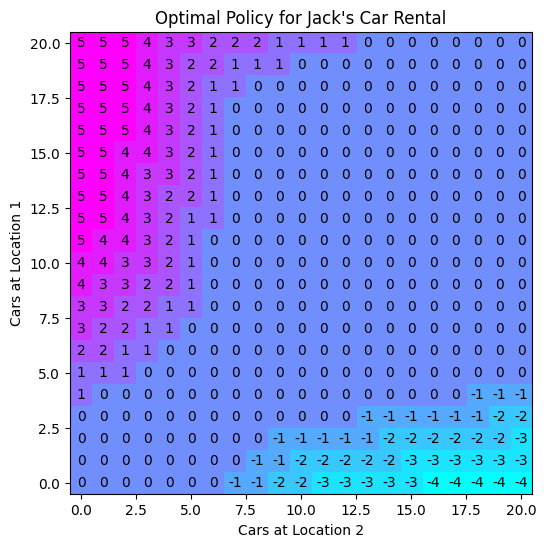

In [24]:
# display final policy as a grid
plt.figure(figsize=(10, 6))
plt.imshow(agent.policy.pi, cmap='cool', origin='lower')
# plt.colorbar(label='Action (Cars moved from loc 1 to loc 2)')
# print actions as text on the grid
for i in range(env.n_rows):
    for j in range(env.n_cols):
        action = agent.policy.pi[i, j]
        plt.text(j, i, str(action), ha='center', va='center', color='black')
plt.title('Optimal Policy for Jack\'s Car Rental')
plt.xlabel('Cars at Location 2')
plt.ylabel('Cars at Location 1')
plt.show()

In [26]:
# create DP agent
agent = DP_Agent(env)

# value iteration
agent.value_iteration()

# print results
print(f"Value iteration steps: {agent.n_value_iter}")

Precomputing Poisson probabilities...
Starting value iteration...
Value iteration #1, delta: 262.4097
Value iteration #2, delta: 100.4035
Value iteration #3, delta: 76.2332
Value iteration #4, delta: 54.9194
Value iteration #5, delta: 39.3458
Value iteration #6, delta: 28.7356
Value iteration #7, delta: 22.4737
Value iteration #8, delta: 17.5150
Value iteration #9, delta: 13.6189
Value iteration #10, delta: 10.5761
Value iteration #11, delta: 8.2070
Value iteration #12, delta: 6.3662
Value iteration #13, delta: 4.9372
Value iteration #14, delta: 3.8285
Value iteration #15, delta: 2.9685
Value iteration #16, delta: 2.3020
Value iteration #17, delta: 1.7854
Value iteration #18, delta: 1.3849
Value iteration #19, delta: 1.0742
Value iteration #20, delta: 0.8333
Value iteration #21, delta: 0.6463
Value iteration #22, delta: 0.5013
Value iteration #23, delta: 0.3889
Value iteration #24, delta: 0.3017
Value iteration #25, delta: 0.2340
Value iteration #26, delta: 0.1815
Value iteration #27, 

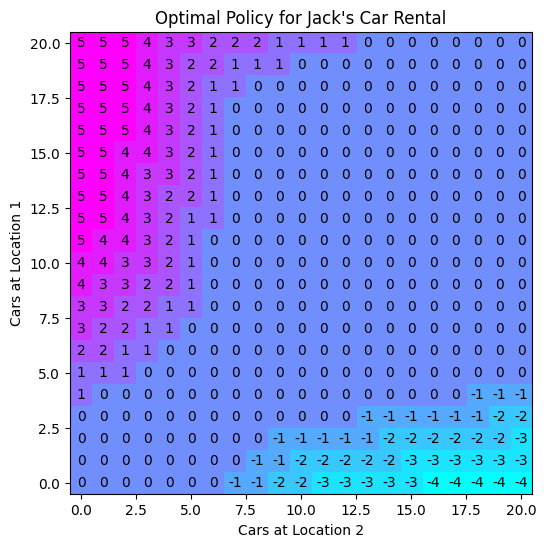

In [27]:
# display final policy as a grid
plt.figure(figsize=(10, 6))
plt.imshow(agent.policy.pi, cmap='cool', origin='lower')
# plt.colorbar(label='Action (Cars moved from loc 1 to loc 2)')
# print actions as text on the grid
for i in range(env.n_rows):
    for j in range(env.n_cols):
        action = agent.policy.pi[i, j]
        plt.text(j, i, str(action), ha='center', va='center', color='black')
plt.title('Optimal Policy for Jack\'s Car Rental')
plt.xlabel('Cars at Location 2')
plt.ylabel('Cars at Location 1')
plt.show()